In [1]:
# Load standard modules
import os
import numpy as np
import json
import math
import matplotlib.pyplot as plt

from datetime import datetime, date, timedelta
#import xarray as xr
import zarr

# Pytorch modules
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

# cuda setup, set seed for reproducability 
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
set_seed(41)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print(f"Using device: {device}")


# PyTorch Lightning
#import pytorch_lightning as pl
#from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Set torch dtype to float64
torch.set_default_dtype(torch.float64)

# Set model path
import sys
sys.path.append('/home.ufs/tm3076/swot_SUM03/SWOT_project/SWOT-inpainting-DL/src')
import simvip_model
import data_loaders
#import trainers



import torch
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(i))

from importlib import reload
#simvip_model = reload(simvip_model)
data_loaders = reload(data_loaders)
#trainers = reload(trainers)


print(f"Using {torch.get_num_threads()} threads!")

#from lightning_fabric.utilities import optimizer


import dask
dask.config.set(scheduler='synchronous')


Using device: cuda:0


/home.ufs/tm3076/swot_SUM03/miniconda3/envs/python11_pytorch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home.ufs/tm3076/swot_SUM03/miniconda3/envs/python11_pytorch/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


_CudaDeviceProperties(name='Tesla V100S-PCIE-32GB', major=7, minor=0, total_memory=32510MB, multi_processor_count=80)
_CudaDeviceProperties(name='Tesla V100S-PCIE-32GB', major=7, minor=0, total_memory=32510MB, multi_processor_count=80)
Using 40 threads!


In [2]:
import numpy as np

In [3]:
import dask
import xarray as xr

In [13]:
model_hparams = {'Number_timesteps': 20,
                 'alpha0': 1,
                 'alpha1': 10,
                 'alpha2': 10,
                 'batch_size': 5,
                 'drop': 0.2,
                 'drop_path': 0.15,
                 'in_mask_list': ['cloud'],
                 'in_transform_list': ['std_mean_sst_norm'],
                 'infields': ['zarr_llc4320_SST_tiles_4km'],
                 'lr': 3e-05,
                 'mean_ssh': 0.074,
                 'mean_sst': 293.307,
                 'model_name': 'TEST',
                 'model_type': 'gSTA',
                 'multiprocessing': False,
                 'out_mask_list': [None],
                 'out_transform_list': ['std_mean_sst_norm'],
                 'outfields': ['zarr_llc4320_SST_tiles_4km'],
                 'std_ssh': 0.0986,
                 'std_sst': 0.8726}

In [14]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# Modules for loading data, set data pathimport urllib
DATASET_PATH = '/swot/SUM03/tatsu_monkman/pytorch_learning_tiles'
CHECKPOINT_PATH = '/swot/SUM03/tatsu_monkman/Inpainting_project_dir/Models/SimVip_tune_norms/checkpoints'
DRIVE_PATH = "."

device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
if device == "cpu":
    n_cpus = 0
    multiprocessing = False
else:
    # Get available CPUs for parallel loading
    n_cpus = torch.get_num_threads()
    multiprocessing = True
print(f"Using device {device} on {n_cpus} cpus with multiprocessing={multiprocessing}")
multiprocessing = False
n_cpus = 0

mid_timestep = 100
N_t = model_hparams["Number_timesteps"]
#pre-computed global normalisation stats
mean_ssh = model_hparams["mean_ssh"]
std_ssh = model_hparams["std_ssh"]
mean_sst = model_hparams["mean_sst"]
std_sst = model_hparams["std_sst"]

# Lambda transforms to apply to input fields
transforms = {"std_ssh_norm": lambda x: x/std_ssh,
            "std_sst_norm": lambda x: x/std_sst,
            "std_mean_ssh_norm": lambda x: (x-np.mean(x))/std_ssh,
            "std_mean_sst_norm": lambda x: (x-np.mean(x))/std_sst,
            "std_global_mean_ssh_norm": lambda x: (x-mean_ssh)/std_ssh,
            "std_global_mean_sst_norm": lambda x: (x-mean_sst)/std_sst,
            "no_transform": lambda x: x,
                }

infields = model_hparams["infields"]
outfields = model_hparams["outfields"]
in_mask_list = model_hparams["in_mask_list"]
out_mask_list = model_hparams["out_mask_list"]
in_transform_strlist = model_hparams["in_transform_list"]
out_transform_strlist = model_hparams["out_transform_list"]
in_transform_list = [transforms[key] for key in in_transform_strlist]
out_transform_list = [transforms[key] for key in out_transform_strlist]

#patch_coords = np.load(f'{DATASET_PATH}/np_SST_masks/x_y_coordinates.npy')
patch_coords = np.load(f'{DATASET_PATH}/zarred_UVSST_x_y_coordinates_noland_nonan.npy')
batch_size = 5

# Data loader 
full_dataset = torch.utils.data.ConcatDataset([data_loaders.llc4320_dataset(DATASET_PATH, i_mid_timestep, N_t, patch_coords, 
                                                                            infields, outfields, in_mask_list, out_mask_list, 
                                                                            in_transform_list, out_transform_list, 
                                                                            multiprocessing = multiprocessing
                                                                           ) for i_mid_timestep in range(30,360,5)])

# Split into train, validation, and test data
train_length = int(0.7*len(full_dataset))
validation_length = int(0.2*len(full_dataset))
test_length = len(full_dataset) - train_length - validation_length
train_dataset, validation_dataset, test_dataset = torch.utils.data.random_split(full_dataset, (train_length, validation_length, test_length))

# Verify size of datasets
print(f"size train_dataset: {len(train_dataset)}")
print(f"size validation_dataset: {len(validation_dataset)}")
print(f"size test_dataset: {len(test_dataset)}")

def worker_init_fn(worker_id):
    worker_info = torch.utils.data.get_worker_info()

train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=n_cpus, worker_init_fn = worker_init_fn, persistent_workers=multiprocessing)
val_data_loader   = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True, num_workers=n_cpus, worker_init_fn = worker_init_fn, persistent_workers=multiprocessing)
test_data_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=n_cpus, worker_init_fn = worker_init_fn, persistent_workers=multiprocessing)


Using device cuda:0 on 40 cpus with multiprocessing=True
size train_dataset: 15107
size validation_dataset: 4316
size test_dataset: 2159


In [26]:
for (x, y, metadata) in test_data_loader:
    break

In [27]:
metadata

{'patch_ID': ['067', '178', '065', '385', '065'],
 'mid_timestep': tensor([280, 190,  85, 295, 315]),
 'patch_coords': tensor([[-167.0000,   32.0000,   67.0000],
         [-155.0000,   44.0000,  178.0000],
         [-131.0000,   35.0000,  107.0000],
         [-165.5000,   45.5000,  385.0000],
         [ 167.5000,   45.5000,  376.0000]]),
 'latitude': tensor([[[29.6658, 29.6667, 29.6675,  ..., 29.6675, 29.6667, 29.6658],
          [29.7021, 29.7029, 29.7037,  ..., 29.7037, 29.7029, 29.7021],
          [29.7384, 29.7392, 29.7400,  ..., 29.7400, 29.7392, 29.7384],
          ...,
          [34.2030, 34.2040, 34.2050,  ..., 34.2050, 34.2040, 34.2030],
          [34.2393, 34.2403, 34.2412,  ..., 34.2412, 34.2403, 34.2393],
          [34.2755, 34.2765, 34.2775,  ..., 34.2775, 34.2765, 34.2755]],
 
         [[41.6558, 41.6571, 41.6583,  ..., 41.6583, 41.6571, 41.6558],
          [41.6920, 41.6932, 41.6945,  ..., 41.6945, 41.6932, 41.6920],
          [41.7282, 41.7294, 41.7307,  ..., 41.7307, 4

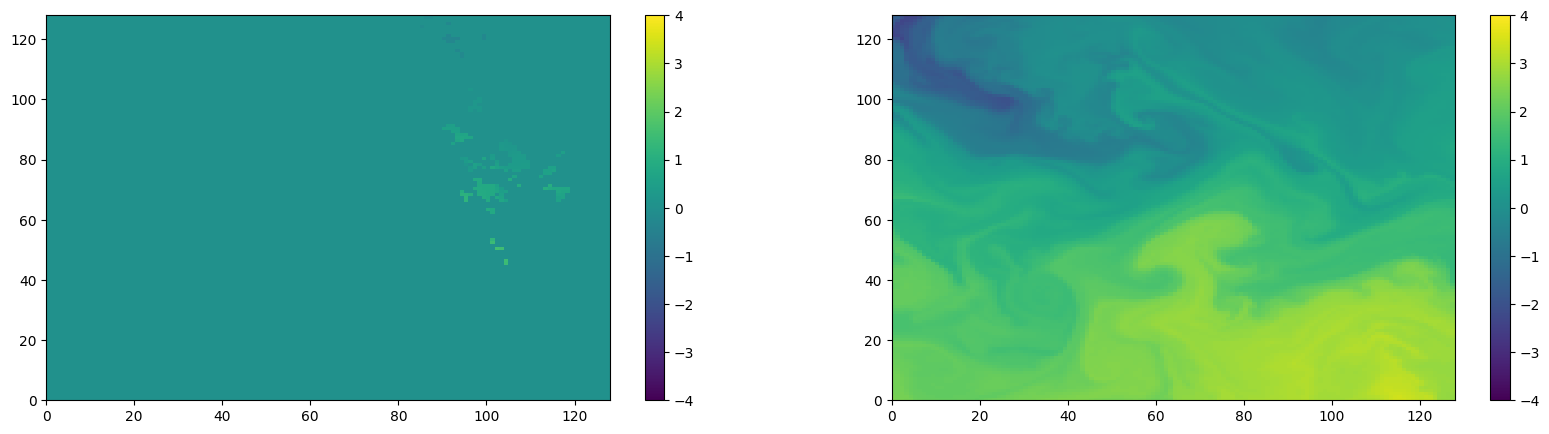

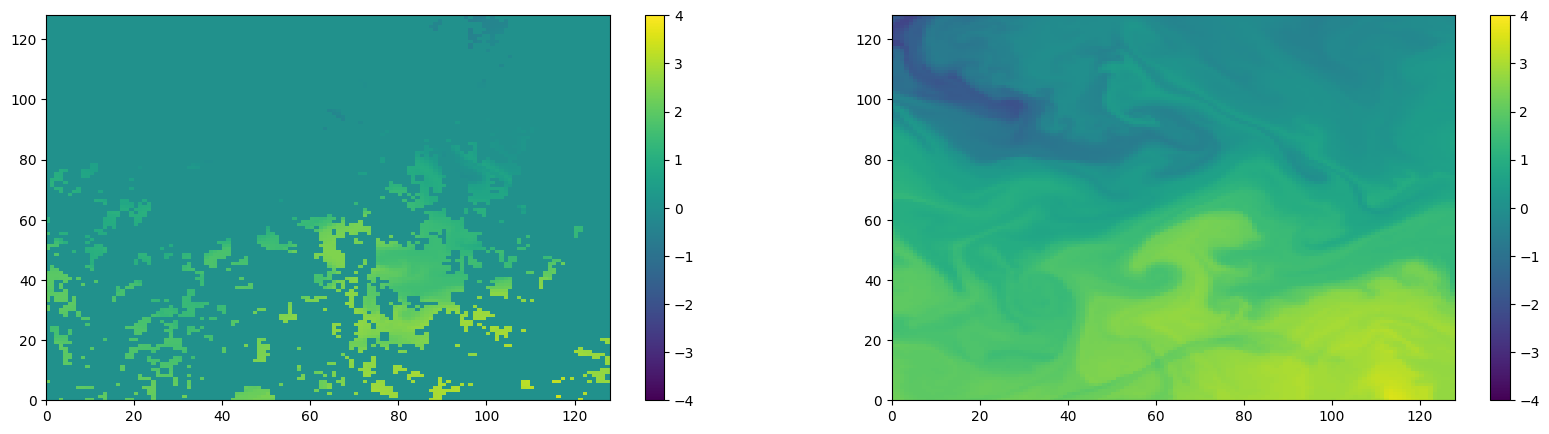

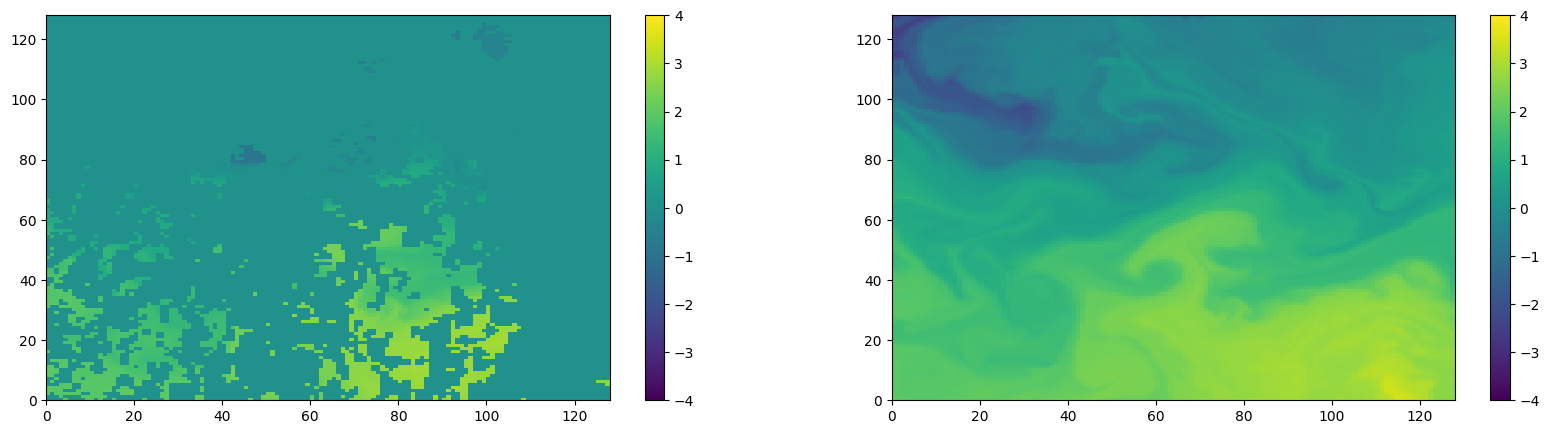

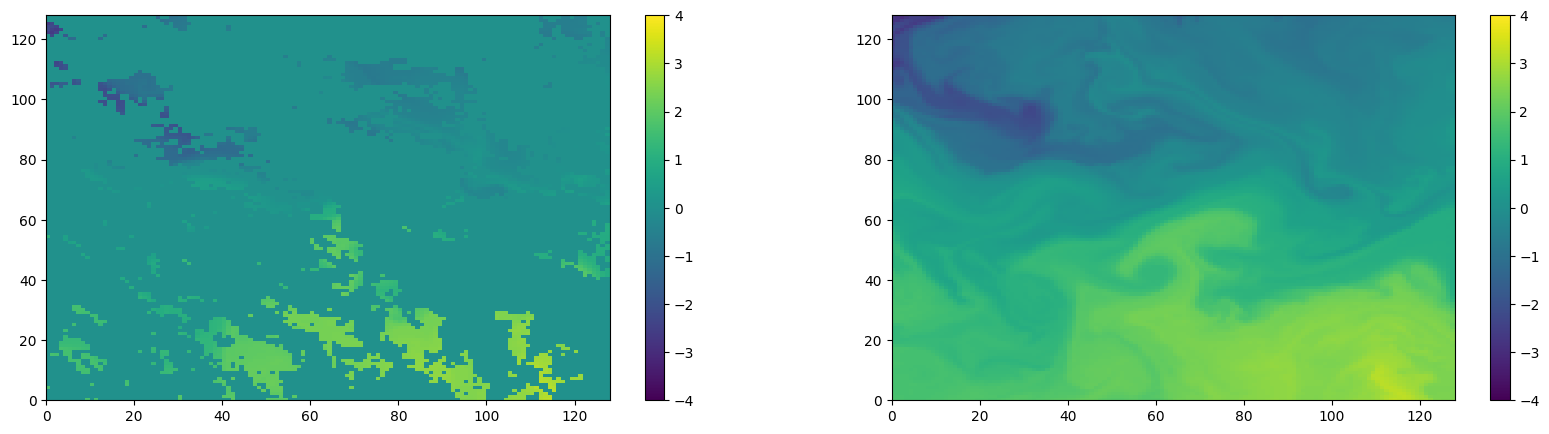

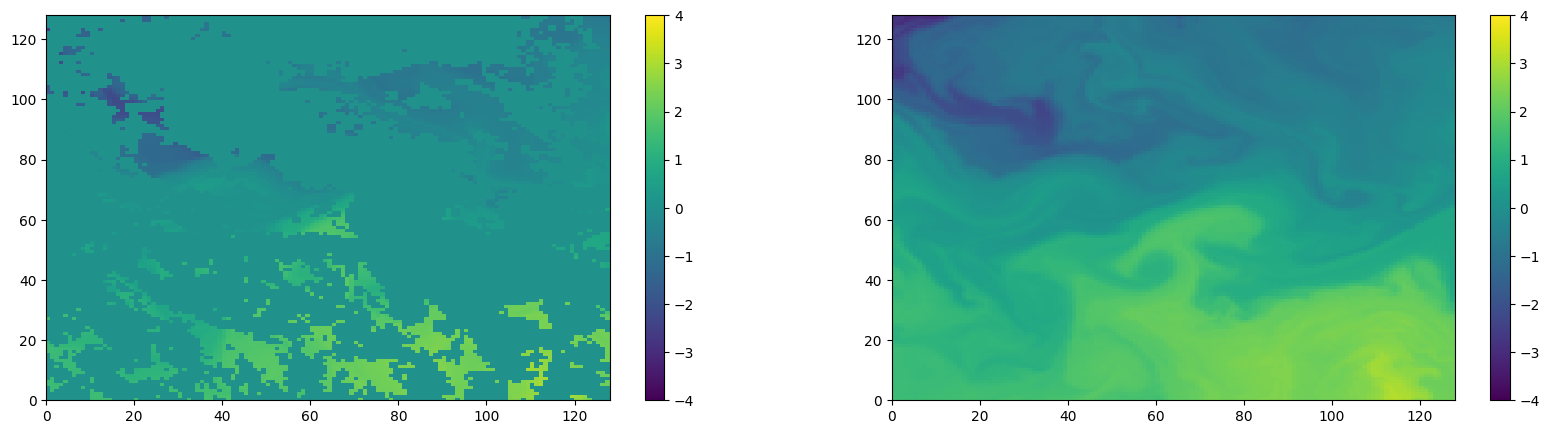

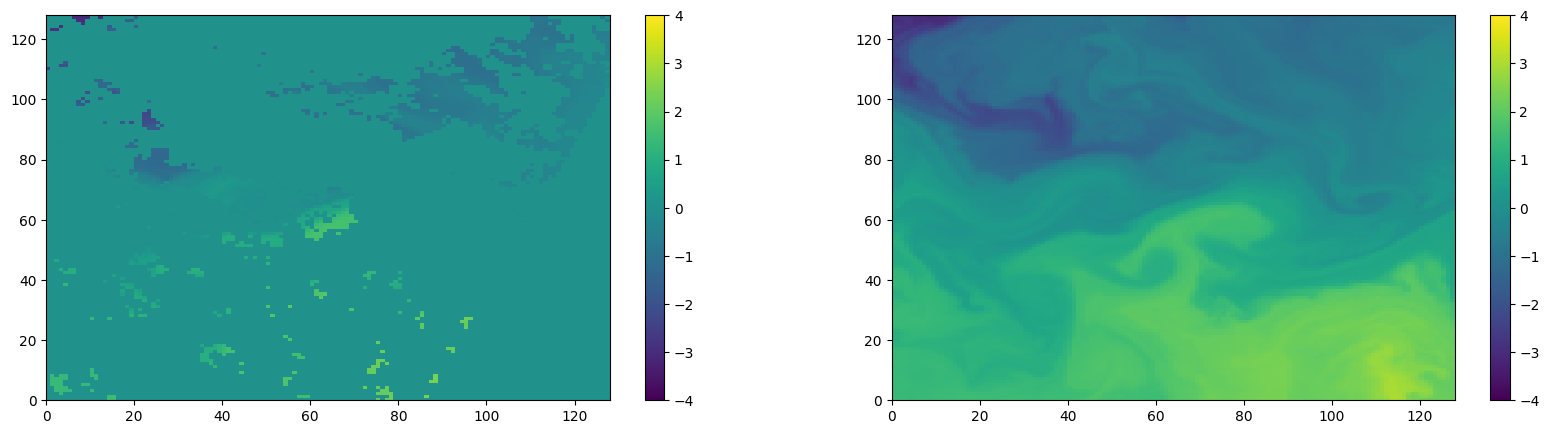

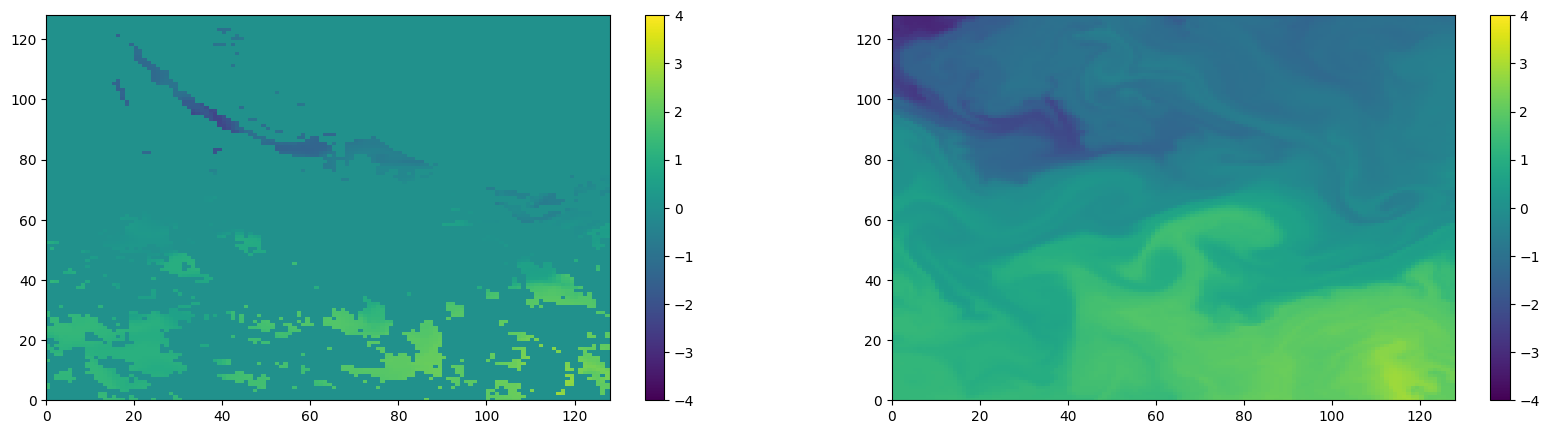

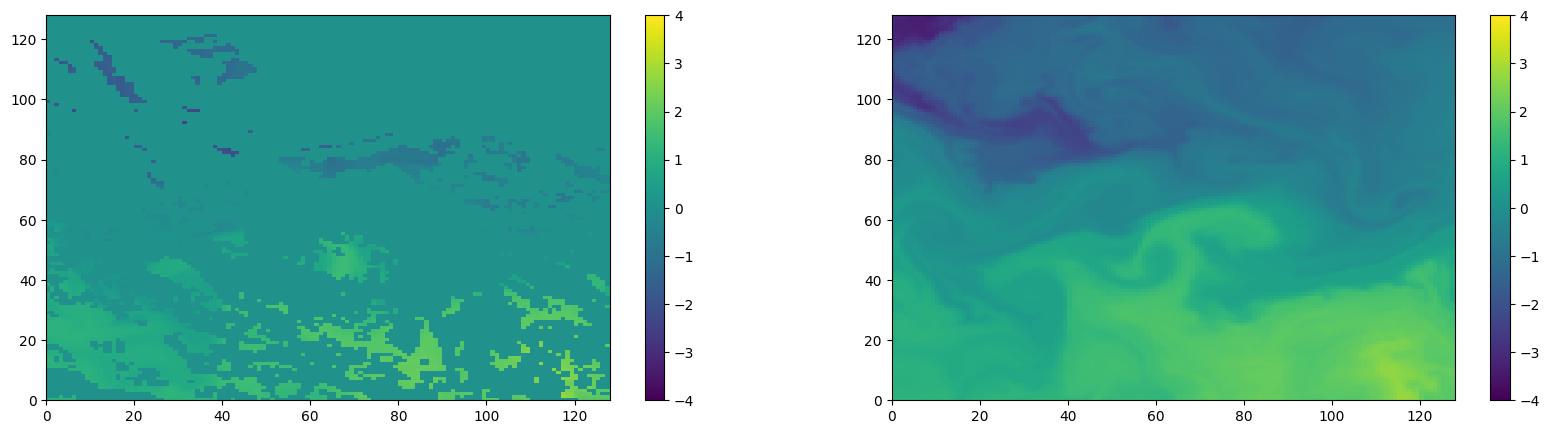

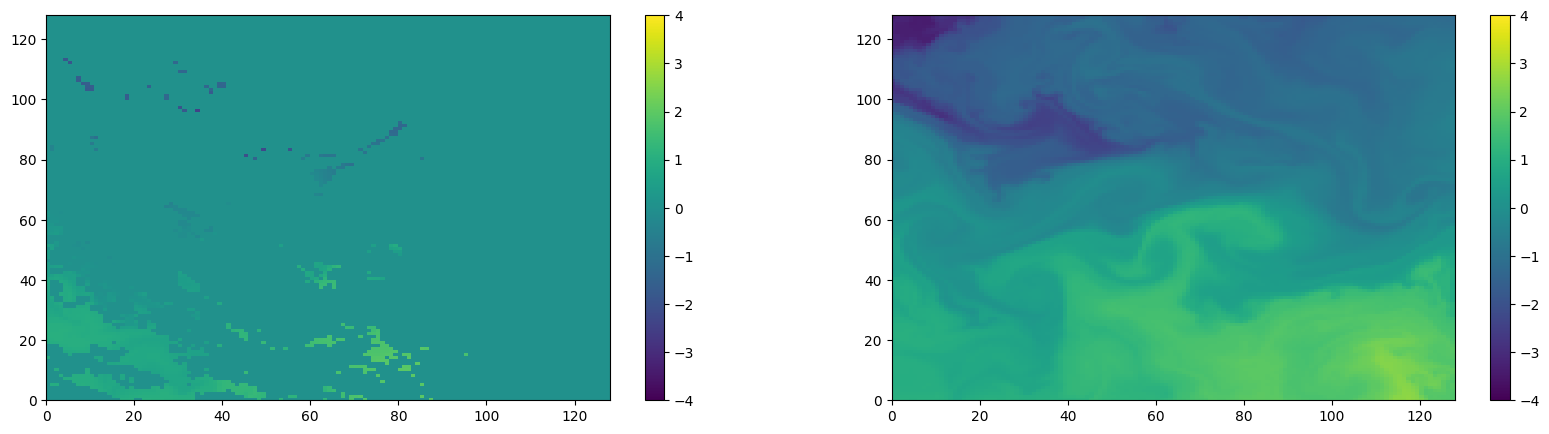

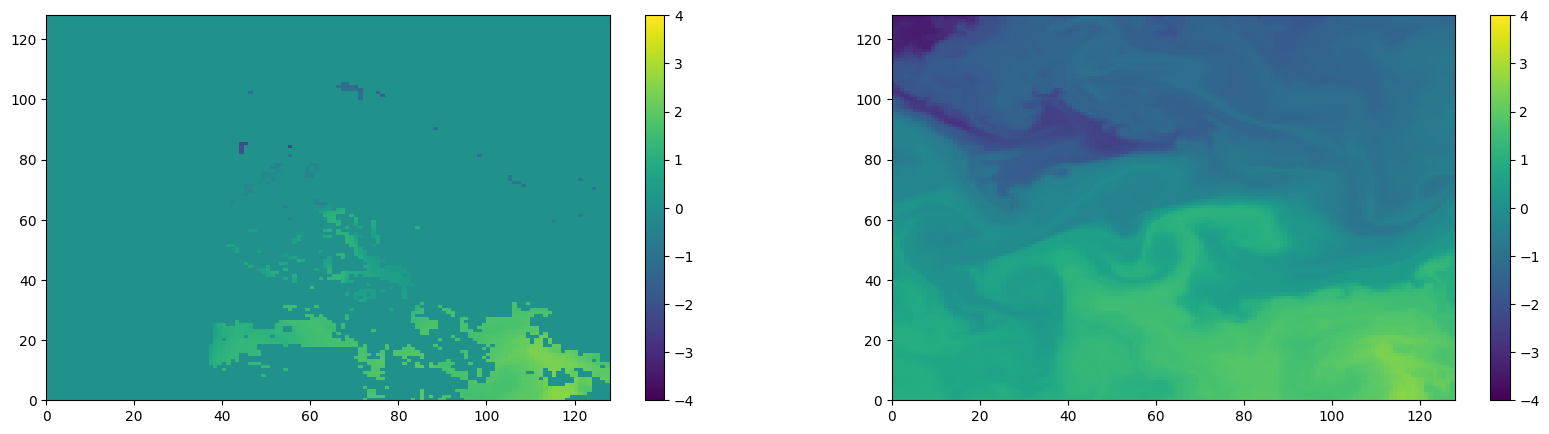

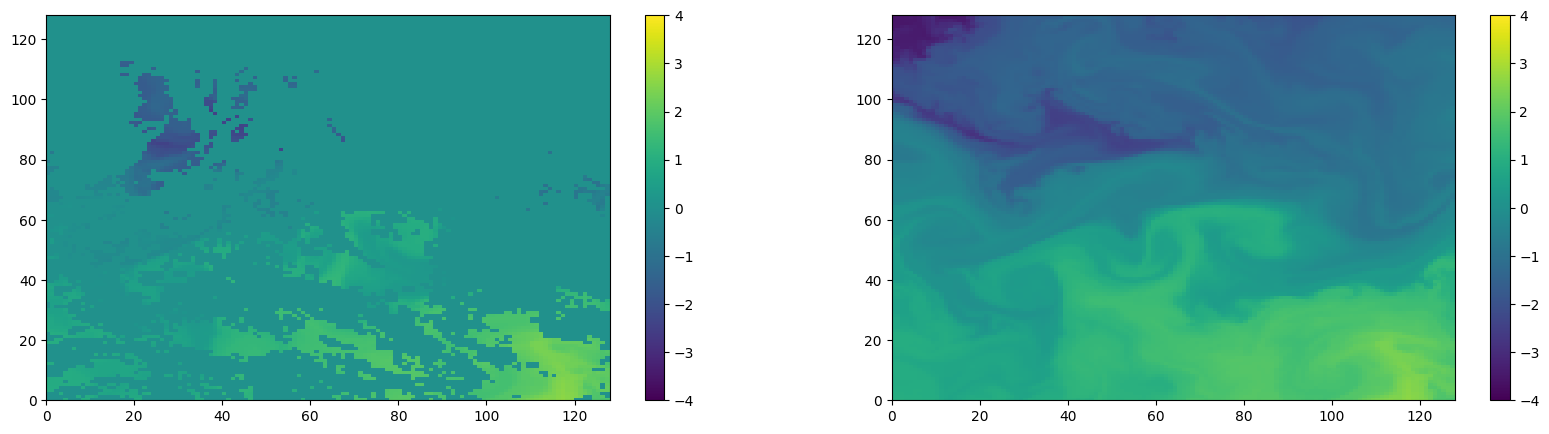

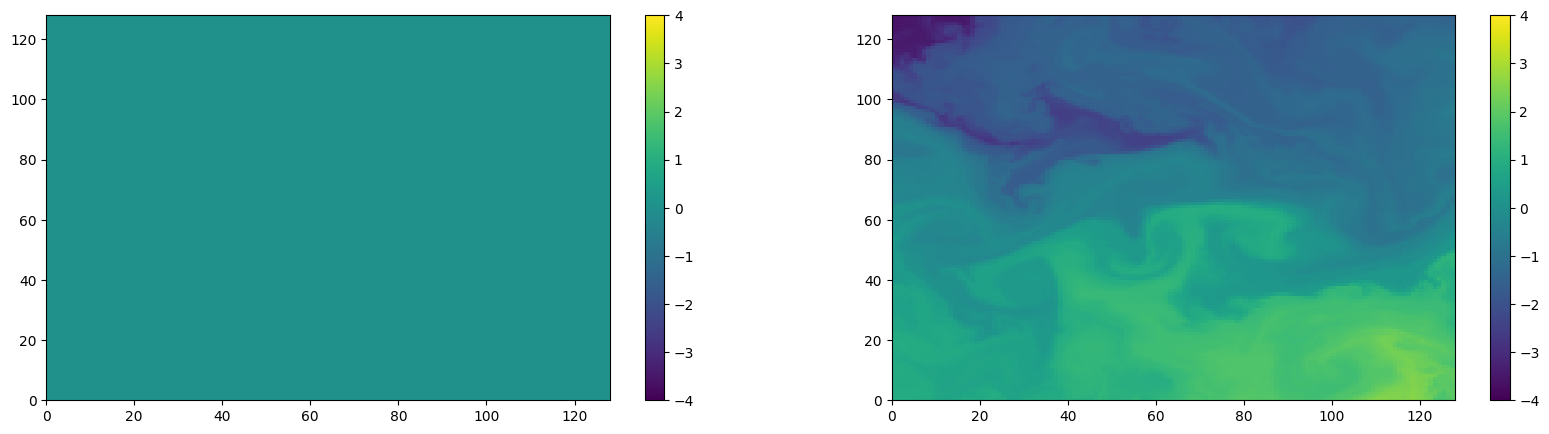

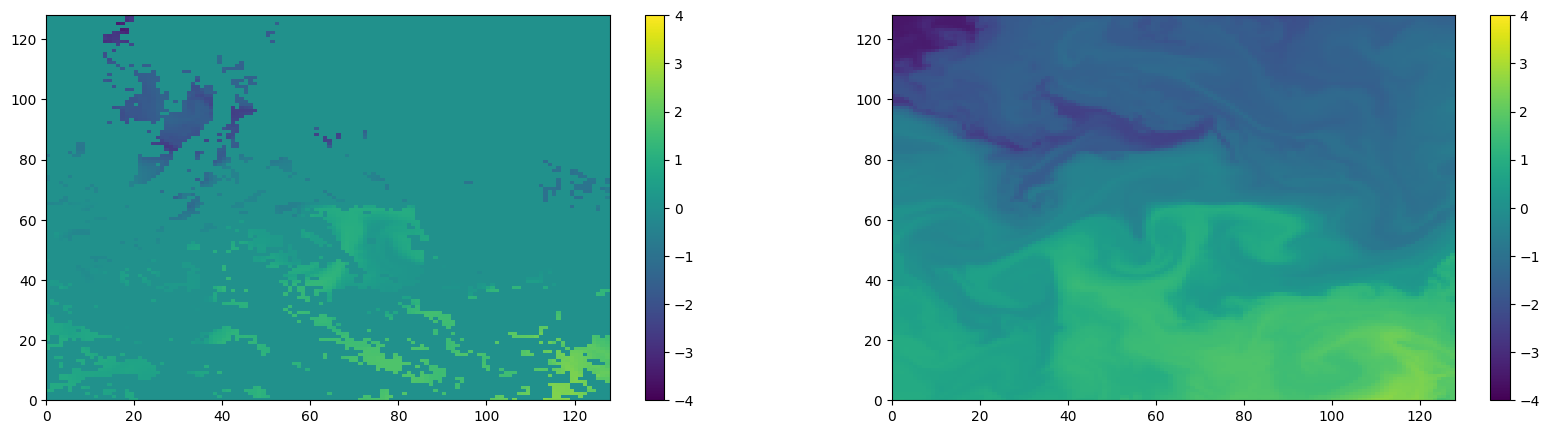

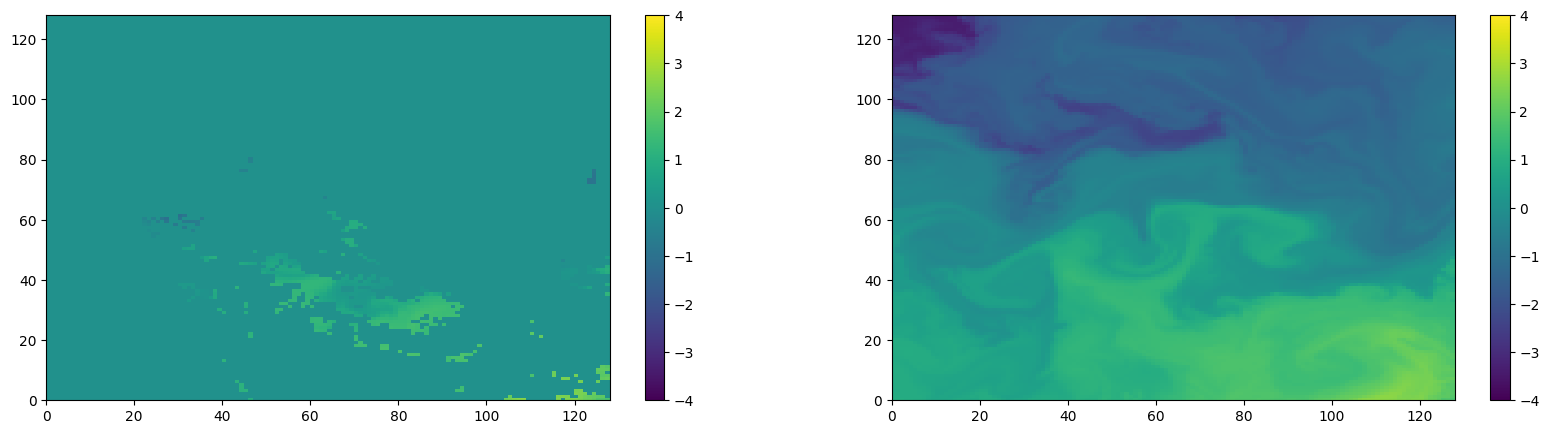

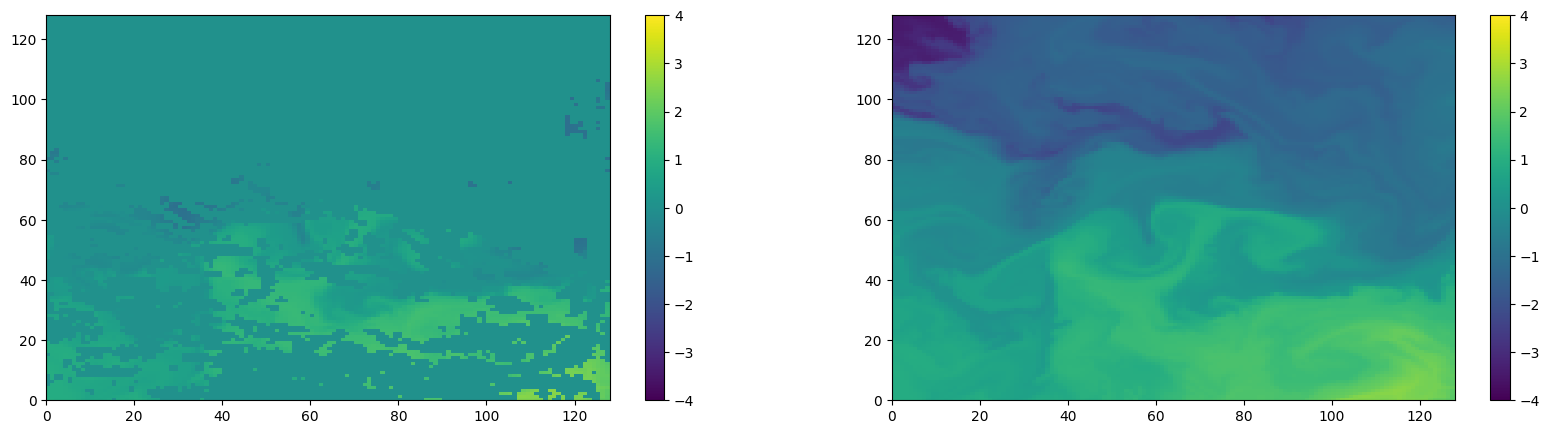

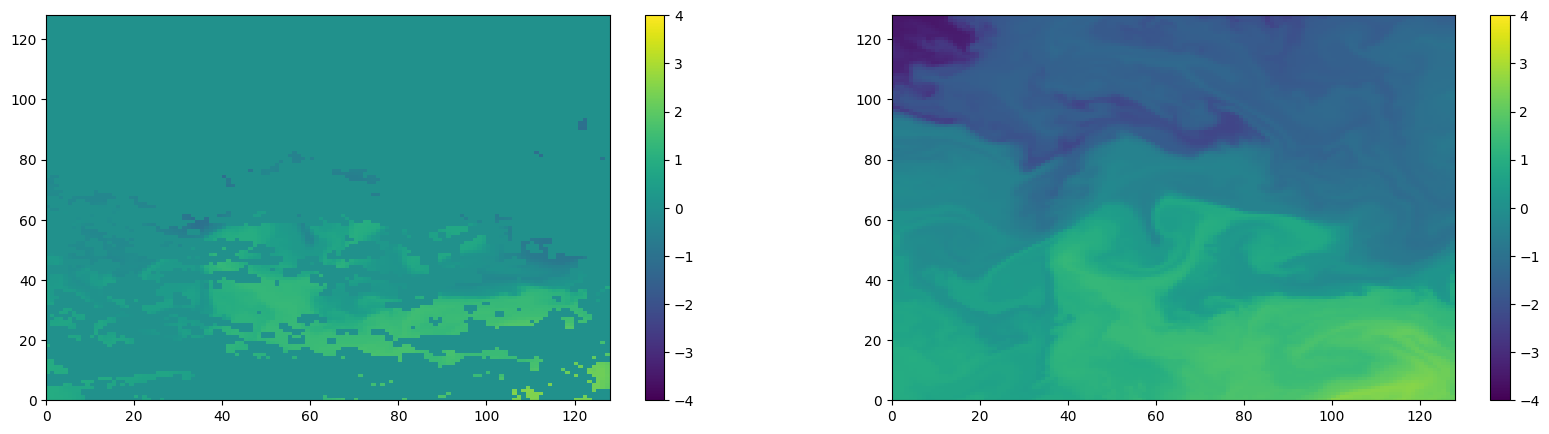

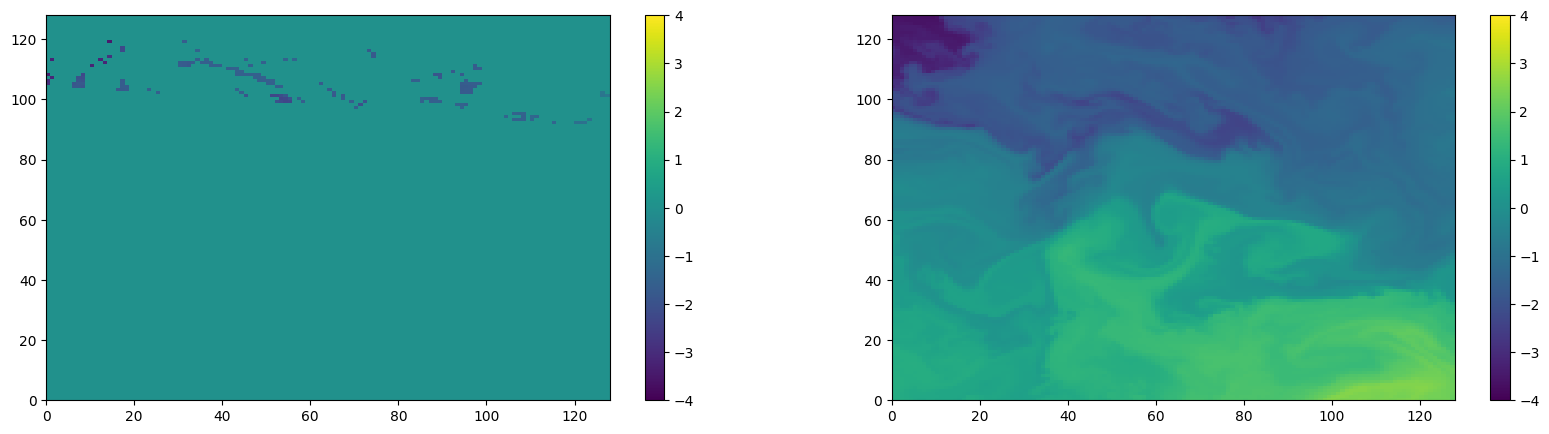

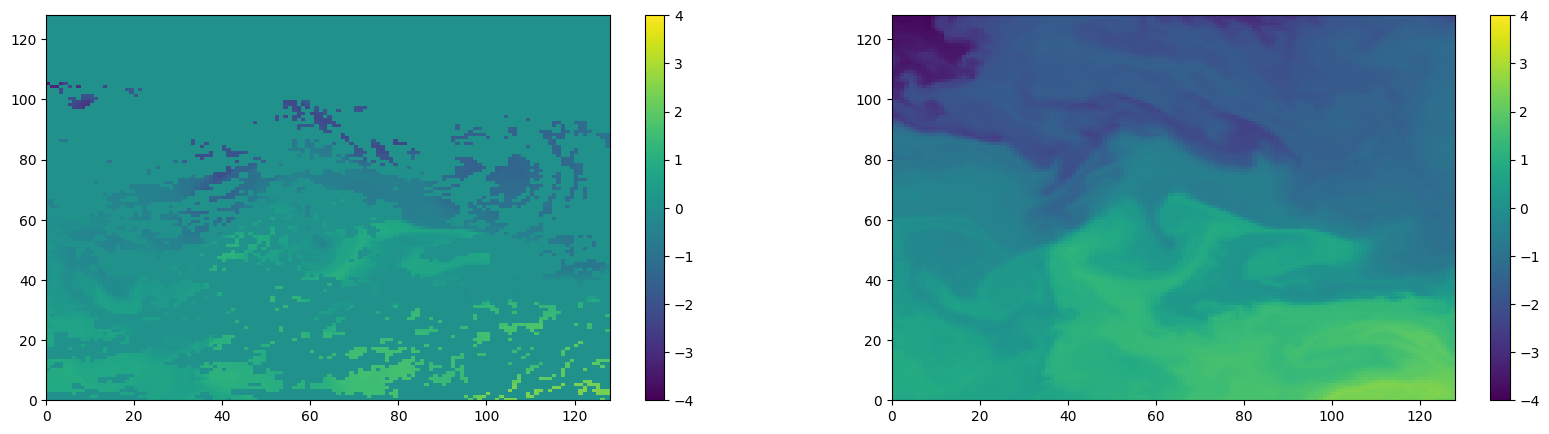

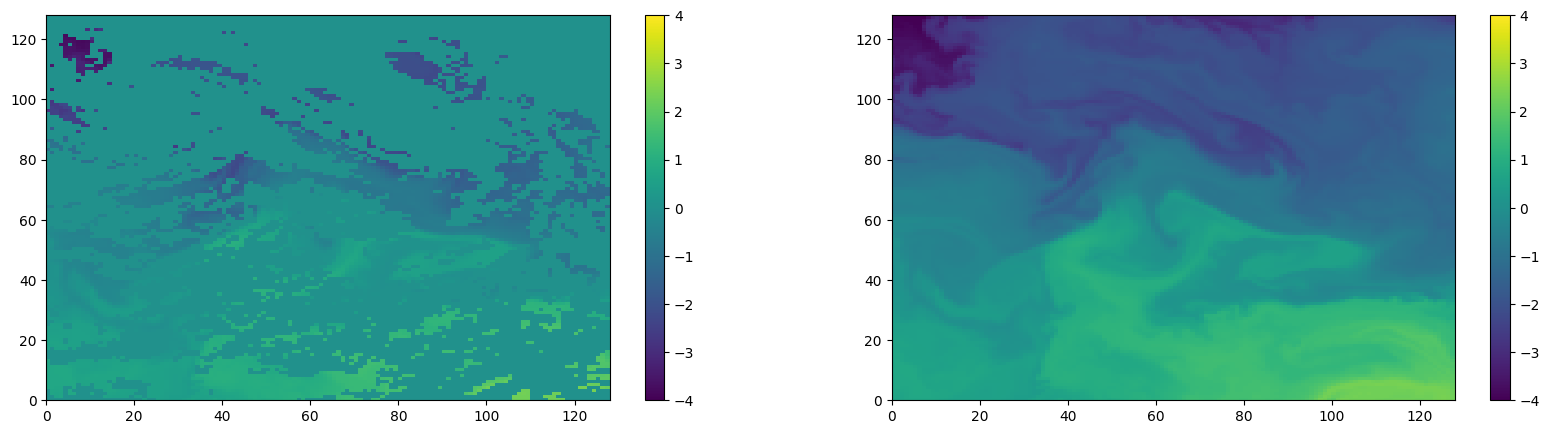

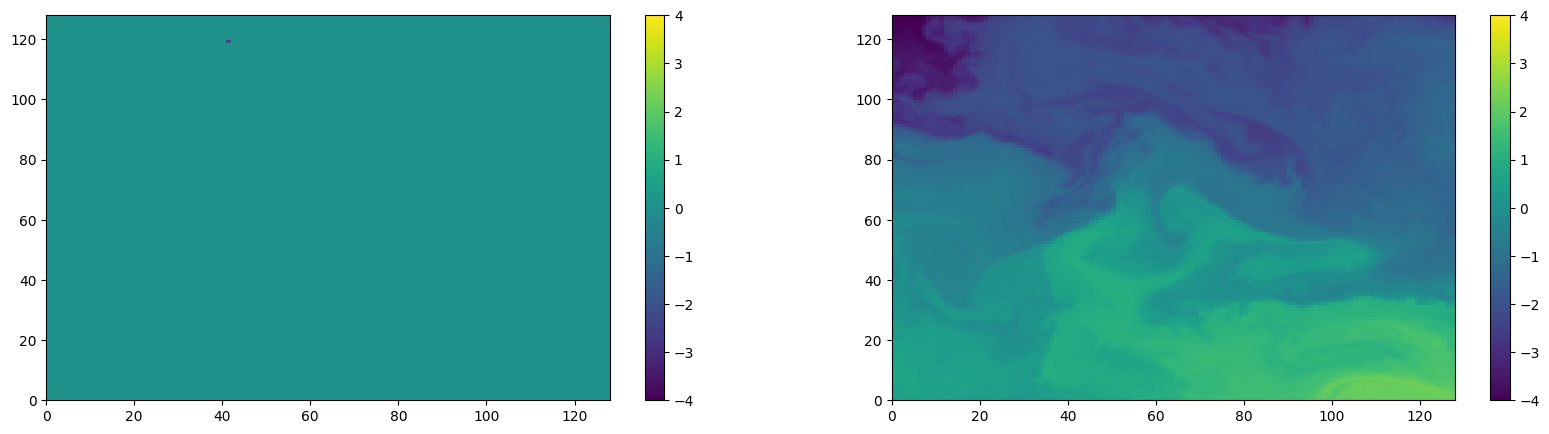

In [30]:
tile = 2
for i in range(20):
    fig, axs = plt.subplots(1,2,figsize=(20,5))
    im0 = axs[0].pcolor(x[tile,i,0],vmin=-4,vmax=4)
    im1 = axs[1].pcolor(y[tile,i,0],vmin=-4,vmax=4)
    plt.colorbar(im0,ax=axs[0])
    plt.colorbar(im1,ax=axs[1])
    plt.show()
    plt.close()

In [30]:
cloud_masks = get_cloud_mask_timeseries("004", 20)

<xarray.DataArray 'sst_filtered_q5' (time: 20, x: 128, y: 128)> Size: 3MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0.

In [34]:
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

Number_timesteps=30
alpha0=0
alpha1=0
alpha2=0
lr=0.0001
# Friday Mar 28 9:45AM
model_hparams = {"model_name":"SimVip_gsta",
                  "Number_timesteps":N_t,
                  "alpha0":1,
                  "alpha1":50,
                  "alpha2":50,
                  "lr":3e-5,
                  "drop":.2,
                  "drop_path":.15,
                  "model_type":"gsta",
                  "multiprocessing":multiprocessing,
                 "infields":infields,
                 "outfields":outfields,
                 "in_mask_list":in_mask_list,
                 "out_mask_list":out_mask_list,
                }

model = simvip_model.SimVP_Model_no_skip_sst(in_shape=(model_hparams["Number_timesteps"],2,128,128),**model_hparams)

optimizer = optim.AdamW(model.parameters(), lr=model_hparams["lr"])
#lr_scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100,500], gamma=0.1)
#        return {"optimizer":optimizer, "lr_scheduler":lr_scheduler}
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

class GradientDifferenceLoss(nn.Module):
    def __init__(self):
        super(GradientDifferenceLoss, self).__init__()
    
    def forward(self, inputs, targets):
        gradient_diff = (inputs.diff(axis=-1)-targets.diff(axis=-1)).pow(2) + (inputs.diff(axis=-2)-targets.diff(axis=-2)).pow(2)
        loss_gdl = gradient_diff.sum()/inputs.numel()
        return loss_gdl


class MSE_and_GDL(nn.Module):
    def __init__(self):
        super(MSE_and_GDL, self).__init__()

    def forward(self, inputs, targets, lambda_mse, lambda_gdl):
        squared_error = (inputs - targets).pow(2)
        gradient_diff_i = (inputs.diff(axis=-1)-targets.diff(axis=-1)).pow(2)
        gradient_diff_j =  (inputs.diff(axis=-2)-targets.diff(axis=-2)).pow(2)
        loss = (lambda_mse*squared_error.sum() + lambda_gdl*gradient_diff_i.sum() + lambda_gdl*gradient_diff_j.sum())/inputs.numel()
        return loss




In [31]:
inputs = torch.tensor(inputs,requires_grad = True)

NameError: name 'inputs' is not defined

In [38]:
for i, data in enumerate(train_data_loader):
    print(i)
    # Every data instance is an input + target field pair
    inputs, targets, metadata = data
    inputs, targets = inputs.requires_grad=True, targets
    # Zero your gradients for every batch!
    optimizer.zero_grad()
    # Make predictions for this batch
    outputs = model(inputs)
    print("output")
    # Compute the loss and its gradients
    criterion = MSE_and_GDL()
    loss = criterion(inputs, targets, lambda_mse=1, lambda_gdl=10)
    print("loss")
    loss.backward()
    print("loss.backward()")

0
output
loss


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [23]:
def train_one_epoch(epoch_index, tb_writer, model):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_data_loader):
        # Every data instance is an input + target field pair
        inputs, targets, metadata = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = nn.MSELoss(inputs, targets)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_data_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss




In [24]:
MODEL_NAME = "SimVip_test"

# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/{}_{}'.format(MODEL_NAME,timestamp))
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer, model)

    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_data_loader):
            vinputs, vtargets, vmetadata = vdata
            voutputs = model(vinputs)
            vloss = MSE_and_GDL(voutputs, vtargets)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    # Log the running loss averaged per batch
    # for both training and validation
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1



EPOCH 1:


RuntimeError: Boolean value of Tensor with more than one value is ambiguous